# **Klasifikasi sampah**

# **Import Libraries and Tools**

In [ ]:
import os
import numpy as np
import random
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from sklearn.utils import shuffle

# **Import Dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
dataset_path = '/content/drive/MyDrive/Sampah'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Split Data**

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./225,
    validation_split=0.3
)

train_dir = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    subset='training'
)

test_dir = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    subset='validation'
)

Found 8587 images belonging to 10 classes.
Found 3672 images belonging to 10 classes.


# **Data Visualization**

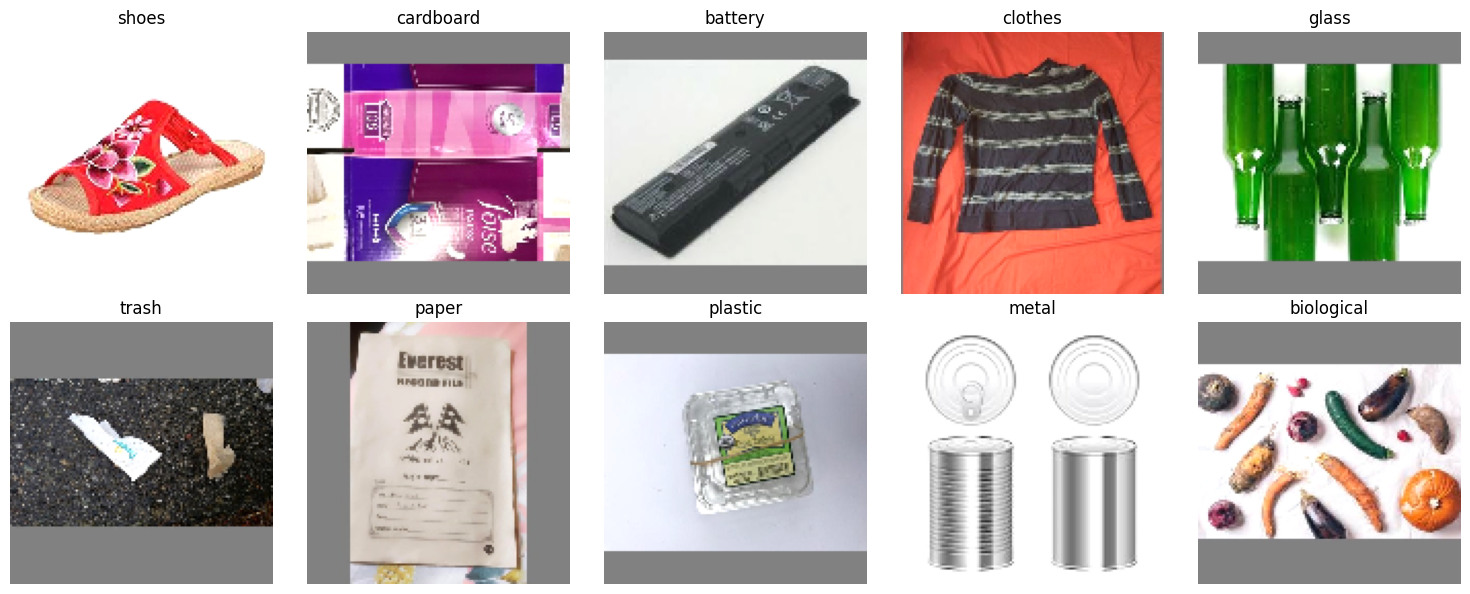

In [ ]:
images, labels = next(train_dir)

class_names = list(train_dir.class_indices.keys())

shown_classes = set()
j = 0

fig, axes = plt.subplots(2,5, figsize=(15,6))
axes = axes.ravel()

while j < 10:
    images, labels = next(train_dir)

    for i in range(len(images)):
        label_index = np.argmax(labels[i])
        label_name = class_names[label_index]

        if label_name not in shown_classes:
            axes[j].imshow(images[i])
            axes[j].axis("off")
            axes[j].set_title(label_name)

            shown_classes.add(label_name)
            j += 1

            if j == 10:
                break

plt.tight_layout()
plt.show()

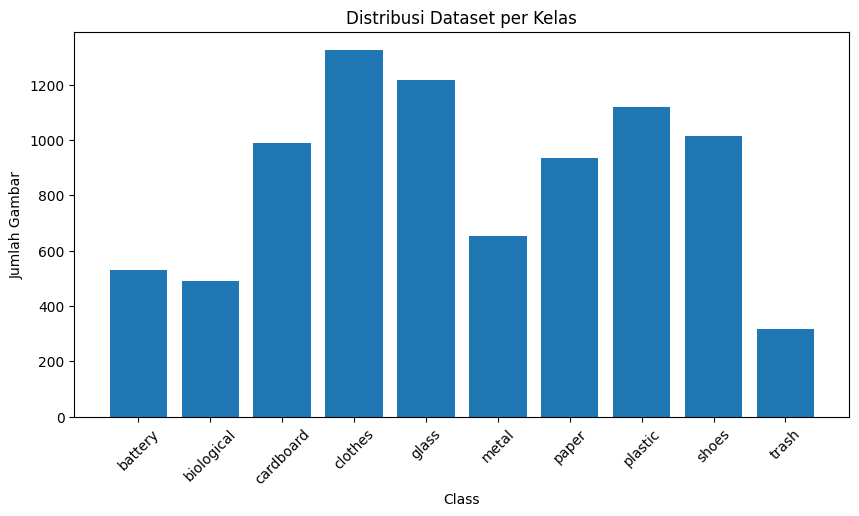

In [ ]:
class_counts = train_dir.classes
class_names = list(train_dir.class_indices.keys())

counts = []
for i in range(len(class_names)):
    counts.append(list(class_counts).count(i))

plt.figure(figsize=(10,5))
plt.bar(class_names, counts)
plt.xticks(rotation=45)
plt.title("Distribusi Dataset per Kelas")
plt.xlabel("Class")
plt.ylabel("Jumlah Gambar")
plt.show()

# **Image Preprocesing**

In [ ]:
# Image Augmentation function
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))
    image = np.array(image) / 255.0
    return image

# Load images and apply augmentation
def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)

# Encoding labels (convert label names to integers)
def encode_label(labels):
    unique_labels = list(train_dir.class_indices.keys())
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded)

# Data generator for batching
def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)
            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels)
            yield batch_images, batch_labels

# **Model VGG16**

In [ ]:
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.applications import VGG16

IMAGE_SIZE = 128

base_model = VGG16(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

for layer in base_model.layers:
    layer.trainable = False

for layer in base_model.layers[-2:]:
    layer.trainable = True

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(train_dir.num_classes, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_dir,
    epochs=5,
    validation_data=test_dir
)

Epoch 1/5
269/269 ━━━━━━━━━━━━━━━━━━━━ 2344s 9s/step - accuracy: 0.5468 - loss: 1.3413 - val_accuracy: 0.7407 - val_loss: 0.7925
Epoch 2/5
269/269 ━━━━━━━━━━━━━━━━━━━━ 55s 204ms/step - accuracy: 0.7333 - loss: 0.8111 - val_accuracy: 0.7919 - val_loss: 0.6546
Epoch 3/5
269/269 ━━━━━━━━━━━━━━━━━━━━ 55s 206ms/step - accuracy: 0.7784 - loss: 0.6771 - val_accuracy: 0.8034 - val_loss: 0.5900
Epoch 4/5
269/269 ━━━━━━━━━━━━━━━━━━━━ 56s 207ms/step - accuracy: 0.8097 - loss: 0.5772 - val_accuracy: 0.8301 - val_loss: 0.5328
Epoch 5/5
269/269 ━━━━━━━━━━━━━━━━━━━━ 55s 205ms/step - accuracy: 0.8354 - loss: 0.5041 - val_accuracy: 0.8361 - val_loss: 0.5090


# **Train and Plots**

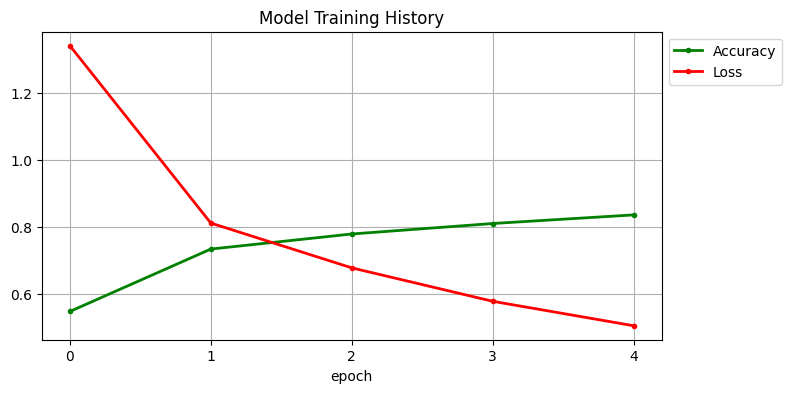

In [ ]:
plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history.history['accuracy'], '.g-', linewidth=2)
plt.plot(history.history['loss'], '.r-', linewidth=2)
plt.title('Model Training History')
plt.xlabel('epoch')
plt.xticks([x for x in range(len(history.history['accuracy']))])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

# **Model Classification Report**

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
import numpy as np
import os

# Extract paths and labels from the test_dir generator
test_paths = test_dir.filepaths
test_integer_labels = test_dir.classes

idx_to_class_name = {v: k for k, v in test_dir.class_indices.items()}
test_labels = [idx_to_class_name[label_idx] for label_idx in test_integer_labels]

test_images = open_images(test_paths)
test_labels_encoded = encode_label(test_labels)

test_predictions = model.predict(test_images)

print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1), target_names=list(test_dir.class_indices.keys())))

115/115 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step
Classification Report:
              precision    recall  f1-score   support

     battery       0.95      0.79      0.86       226
  biological       0.87      0.80      0.83       209
   cardboard       0.91      0.78      0.84       423
     clothes       0.94      0.93      0.93       567
       glass       0.75      0.84      0.80       520
       metal       0.74      0.62      0.68       279
       paper       0.75      0.78      0.76       400
     plastic       0.66      0.81      0.73       479
       shoes       0.91      0.91      0.91       434
       trash       0.66      0.59      0.62       135

    accuracy                           0.81      3672
   macro avg       0.81      0.78      0.80      3672
weighted avg       0.82      0.81      0.81      3672



# **Model Confusion Plot**

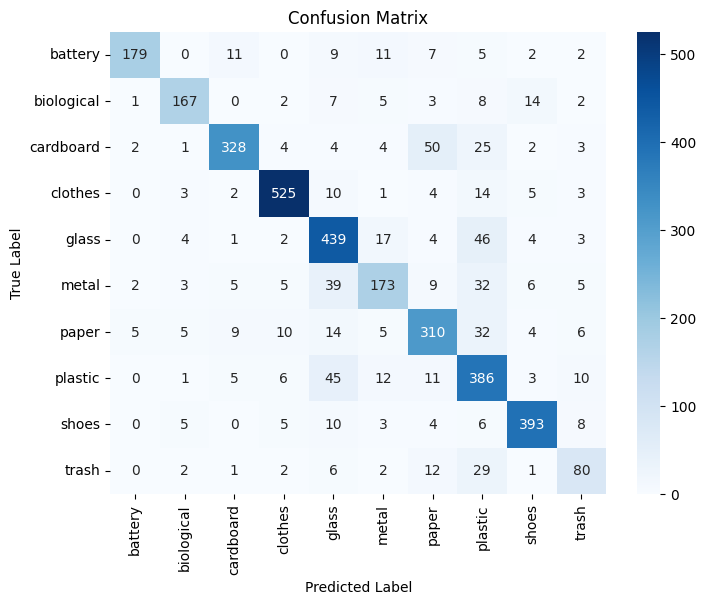

In [ ]:
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=list(test_dir.class_indices.keys()), yticklabels=list(test_dir.class_indices.keys()))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# **ROC Curve**

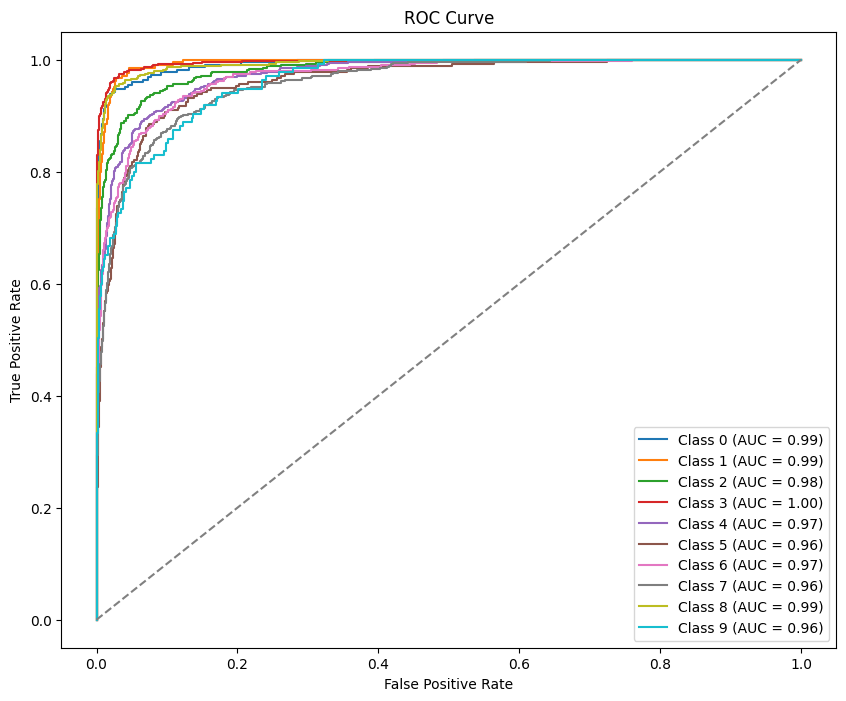

In [ ]:
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(train_dir.num_classes))
test_predictions_bin = test_predictions

fpr, tpr, roc_auc = {}, {}, {}
for i in range(train_dir.num_classes):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
for i in range(train_dir.num_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

# **Save and Load Model**

In [ ]:
model.save('model.h5')

In [ ]:
from tensorflow.keras.models import load_model
model = load_model('model.h5')

# **Detection Model**

In [ ]:
def detect_trash(img_path, model):

    class_labels = list(train_dir.class_indices.keys())

    img = load_img(img_path, target_size=(128,128))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array)

    predicted_index = np.argmax(predictions)
    confidence = predictions[0][predicted_index]

    predicted_class = class_labels[predicted_index]

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediksi: {predicted_class} ({confidence*100:.2f}%)")
    plt.show()

In [ ]:
image_path = ''
detect_trash(image_path,model)